# Section 5: Data Preprocessing

---

In this stage, we transition from "human-readable" data to "machine-optimized" data. We ensure that extreme values (like the Tarrasque’s HP) don't distort the model’s learning and that redundant identifiers are removed.

### TLDR: 
Input: `engineered_bestiary.csv` with 59 columns 

→ 

Output: `preprocessed_bestiary.csv` with 28 columns

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_theme(style="whitegrid")

# Load engineered dataset
engineered_df = pd.read_csv('../data/engineered_bestiary.csv')

# Print dataset info
print("--- Dataset Information ---")
engineered_df.info()

# Display summary statistics
print("\n--- Statistical Summary ---")
display(engineered_df.describe())

# Display first 5 records
print("\n--- First 5 Records ---")
display(engineered_df.head())

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 3658 entries, 0 to 3657
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    3658 non-null   str    
 1   Source                  3658 non-null   str    
 2   Page                    3658 non-null   str    
 3   Size                    3658 non-null   str    
 4   Type                    3658 non-null   str    
 5   Alignment               3658 non-null   str    
 6   AC                      3658 non-null   int64  
 7   HP                      3658 non-null   int64  
 8   Speed                   3658 non-null   str    
 9   Strength                3658 non-null   int64  
 10  Dexterity               3658 non-null   int64  
 11  Constitution            3658 non-null   int64  
 12  Intelligence            3658 non-null   int64  
 13  Wisdom                  3658 non-null   int64  
 14  Charisma               

,AC,HP,Strength,Dexterity,Constitution,Intelligence,Wisdom,Charisma,CR,Size_Rank,...,Type_other,Type_undead,Trait_Count,Action_Count,Is_Legendary,Is_Spellcaster,Max_Speed,Movement_Count,Avg_HP,Max_HP
count,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,...,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000
mean,14.685894,96.116184,15.120831,13.423455,15.318480,10.694369,12.800164,11.664297,5.986844,3.366320,...,0.090760,0.084472,1.894478,1.678786,0.097868,0.331055,38.395298,1.466922,96.116184,144.940678
std,2.965027,99.855364,6.004524,3.339387,4.186191,5.678043,3.550985,5.646058,6.189269,1.046777,...,0.287307,0.278133,1.429911,0.783612,0.297176,0.470657,19.337400,0.637558,99.855364,145.558914
min,5.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000
25%,12.000000,27.000000,11.000000,11.000000,12.000000,6.000000,10.000000,7.000000,1.000000,3.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,30.000000,1.000000,27.000000,45.000000
50%,15.000000,66.000000,15.000000,14.000000,14.000000,11.000000,12.000000,11.000000,4.000000,3.000000,...,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,30.000000,1.000000,66.000000,104.000000
75%,17.000000,135.000000,19.000000,15.000000,18.000000,14.000000,15.000000,16.000000,9.000000,4.000000,...,0.000000,0.000000,3.000000,2.000000,0.000000,1.000000,40.000000,2.000000,135.000000,198.000000
max,25.000000,725.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,6.000000,...,1.000000,1.000000,9.000000,6.000000,1.000000,1.000000,400.000000,4.000000,725.000000,1020.000000



--- First 5 Records ---


,Name,Source,Page,Size,Type,Alignment,AC,HP,Speed,Strength,...,Type_undead,Trait_Count,Action_Count,Is_Legendary,Is_Spellcaster,Max_Speed,Movement_Types,Movement_Count,Avg_HP,Max_HP
0,the demogorgon,imr,53,large,giant,chaotic neutral,15,123,40 ft.,21,...,0,2,2,0,0,40,walk,1,123,195
1,aarakocra,mm14,12,medium,humanoid,neutral good,12,13,"20 ft., fly 50 ft.",10,...,0,1,1,0,0,50,"walk, fly",2,13,24
2,aarakocra aeromancer,mm25,10,medium,elemental,neutral,16,66,"20 ft., fly 50 ft.",10,...,0,0,2,0,1,50,"walk, fly",2,66,108
3,aarakocra simulacrum,skt,188,medium,humanoid,neutral good,12,6,"20 ft., fly 50 ft.",10,...,0,2,1,0,0,50,"walk, fly",2,6,12
4,aarakocra skirmisher,mm25,10,medium,elemental,neutral,12,11,"20 ft., fly 50 ft.",10,...,0,0,1,0,0,50,"walk, fly",2,11,18


## Phase 1: Scaling & Outlier Mitigation
This phase puts all numbers on a compatible mathematical scale so that high-range values (HP) don't "drown out" low-range values (AC).

### 1.1 Outlier Taming (Log Transformation)
* **Conceptual Definition:** Reducing the "stretching" effect of extreme values.
* **Operational Definition:** Applying a natural log ($log(x+1)$) to columns with high skewness, specifically `Avg_HP` and `Max_HP`.
* **Justification:** D&D hit points range from 1 to 600+. Without this, the model might over-prioritize the difference between 500 and 600 HP, while ignoring the vital difference between 10 and 20 HP.

In [ ]:
import numpy as np
import re

# Set Avg_HP
engineered_df['Avg_HP'] = engineered_df['HP']

# Extract Max_HP from HP_Formula
def calculate_max_hp(formula):
    if pd.isna(formula) or str(formula).lower() == 'none':
        return np.nan
    match = re.search(r'(\d+)d(\d+)(?:\s*([\+\-])\s*(\d+))?', str(formula))
    if match:
        num_dice = int(match.group(1))
        die_size = int(match.group(2))
        sign = match.group(3) if match.group(3) else '+'
        bonus = int(match.group(4)) if match.group(4) else 0
        
        return (num_dice * die_size) + bonus if sign == '+' else (num_dice * die_size) - bonus
    return np.nan

# Apply calculation and fill missing values
engineered_df['Max_HP'] = engineered_df['HP_Formula'].apply(calculate_max_hp)
engineered_df['Max_HP'] = engineered_df['Max_HP'].fillna(engineered_df['Avg_HP'])

# Apply Log Transformation
engineered_df['Log_Avg_HP'] = np.log1p(engineered_df['Avg_HP'])
engineered_df['Log_Max_HP'] = np.log1p(engineered_df['Max_HP'])

# Print summary and preview
print("Log Transformation Summary:")
print(engineered_df[['Avg_HP', 'Log_Avg_HP', 'Max_HP', 'Log_Max_HP']].describe())

print("\n--- Transformed HP Preview ---")
display(engineered_df[['Name', 'Avg_HP', 'Log_Avg_HP', 'Max_HP', 'Log_Max_HP']].head())

Log Transformation Summary:
            Avg_HP   Log_Avg_HP       Max_HP   Log_Max_HP
count  3658.000000  3658.000000  3658.000000  3658.000000
mean     96.116184     4.064346   144.877802     4.506698
std      99.855364     1.117210   145.596370     1.071420
min       1.000000     0.693147     3.000000     1.386294
25%      27.000000     3.332205    45.000000     3.828641
50%      66.000000     4.204693   104.000000     4.653960
75%     135.000000     4.912655   198.000000     5.293305
max     725.000000     6.587550  1020.000000     6.928538

--- Transformed HP Preview ---


,Name,Avg_HP,Log_Avg_HP,Max_HP,Log_Max_HP
0,the demogorgon,123,4.820282,195.0,5.278115
1,aarakocra,13,2.639057,24.0,3.218876
2,aarakocra aeromancer,66,4.204693,108.0,4.691348
3,aarakocra simulacrum,6,1.945910,12.0,2.564949
4,aarakocra skirmisher,11,2.484907,18.0,2.944439


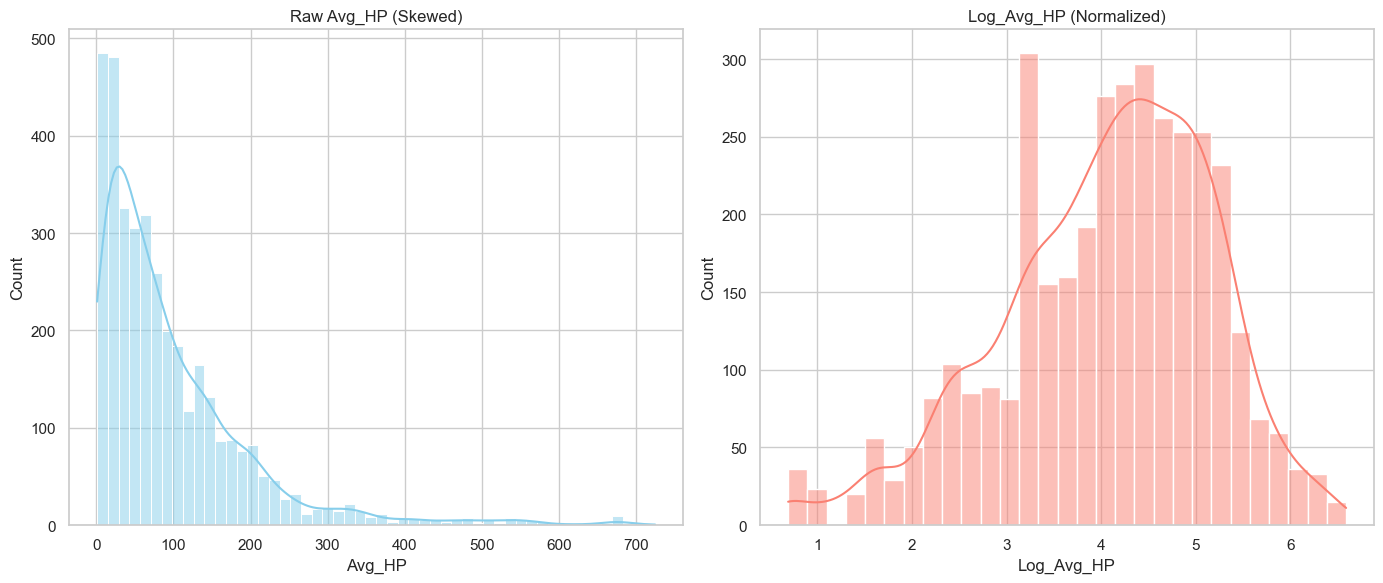

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply transformation
engineered_df['Log_Avg_HP'] = np.log1p(engineered_df['Avg_HP'])

# Create Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Original Distribution
sns.histplot(engineered_df['Avg_HP'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Raw Avg_HP (Skewed)')

# Plot 2: Log Transformed Distribution
sns.histplot(engineered_df['Log_Avg_HP'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Log_Avg_HP (Normalized)')

plt.tight_layout()
plt.show()

Log transformation, specifically using $log(x+1)$, addresses the extreme right-skewness found in Hit Point distributions where a few legendary creatures create a long tail of outliers. By applying this non-linear function, the data is reshaped from a lopsided cluster into a more normal, bell-shaped distribution. The addition of one via the np.log1p function serves as a mathematical safety mechanism to prevent undefined results from zero values, ensuring every monster statistic remains finite and stable for neural network processing.

Unlike standard scaling methods that only modify the range of values, log transformation alters the relationship between data points to prioritize relative growth. This mirrors game balance logic where a 10-point HP increase is significant for a low-level creature but negligible for a high-level dragon. In a raw dataset, a model might overemphasize the gap between 600 and 700 HP while missing the critical survival difference between 10 and 110 HP. The transformation treats percentage changes as the primary signal, stretching out the differences between low-level stats while compressing the gaps between massive values.

This structural change prevents gradient explosion by pulling extreme outliers closer to the mean, which keeps model weights from swinging wildly during training. By narrowing the disparity between the weakest and strongest creatures, the neural network can treat features like Hit Points and Armor Class with equal importance. The resulting visualization shows that the compressed cluster of low-HP monsters is expanded, allowing the model to more accurately distinguish between various Challenge Ratings and achieve faster convergence.

### 1.2 Z-Score Standardization
* **Conceptual Definition:** Centering data around a mean of zero with a standard deviation of one.
* **Operational Definition:** Applied to features following a normal distribution: `AC`, Ability Scores, and `Max_Speed`.
* **Formula:** $$z = \frac{x - \mu}{\sigma}$$
* **Justification:** This ensures that a +1 bonus in AC is weighted similarly to a +1 bonus in Strength.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Define features to standardize
ability_scores = ['Strength', 'Dexterity', 'Constitution', 'Intelligence', 'Wisdom', 'Charisma']
target_features = ['AC'] + ability_scores + ['Max_Speed']

# Initialize and apply StandardScaler
scaler = StandardScaler()

# Create standardized columns with _Z suffix
z_cols = [f"{col}_Z" for col in target_features]
engineered_df[z_cols] = scaler.fit_transform(engineered_df[target_features])

# Print scaling statistics
print("--- Z-Score Scaling Statistics ---")
display(engineered_df[z_cols].describe().round(4).loc[['mean', 'std']])

# Display comparison sample
print("\n--- Raw vs Standardized Comparison ---")
display(engineered_df[['Name', 'AC', 'AC_Z', 'Strength', 'Strength_Z', 'Max_Speed', 'Max_Speed_Z']].head())

--- Z-Score Scaling Statistics ---


,AC_Z,Strength_Z,Dexterity_Z,Constitution_Z,Intelligence_Z,Wisdom_Z,Charisma_Z,Max_Speed_Z
mean,-0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001,1.0001



--- Raw vs Standardized Comparison ---


,Name,AC,AC_Z,Strength,Strength_Z,Max_Speed,Max_Speed_Z
0,the demogorgon,15,0.105951,21,0.979257,40,0.082996
1,aarakocra,12,-0.905982,10,-0.852945,50,0.600199
2,aarakocra aeromancer,16,0.443263,10,-0.852945,50,0.600199
3,aarakocra simulacrum,12,-0.905982,10,-0.852945,50,0.600199
4,aarakocra skirmisher,12,-0.905982,10,-0.852945,50,0.600199


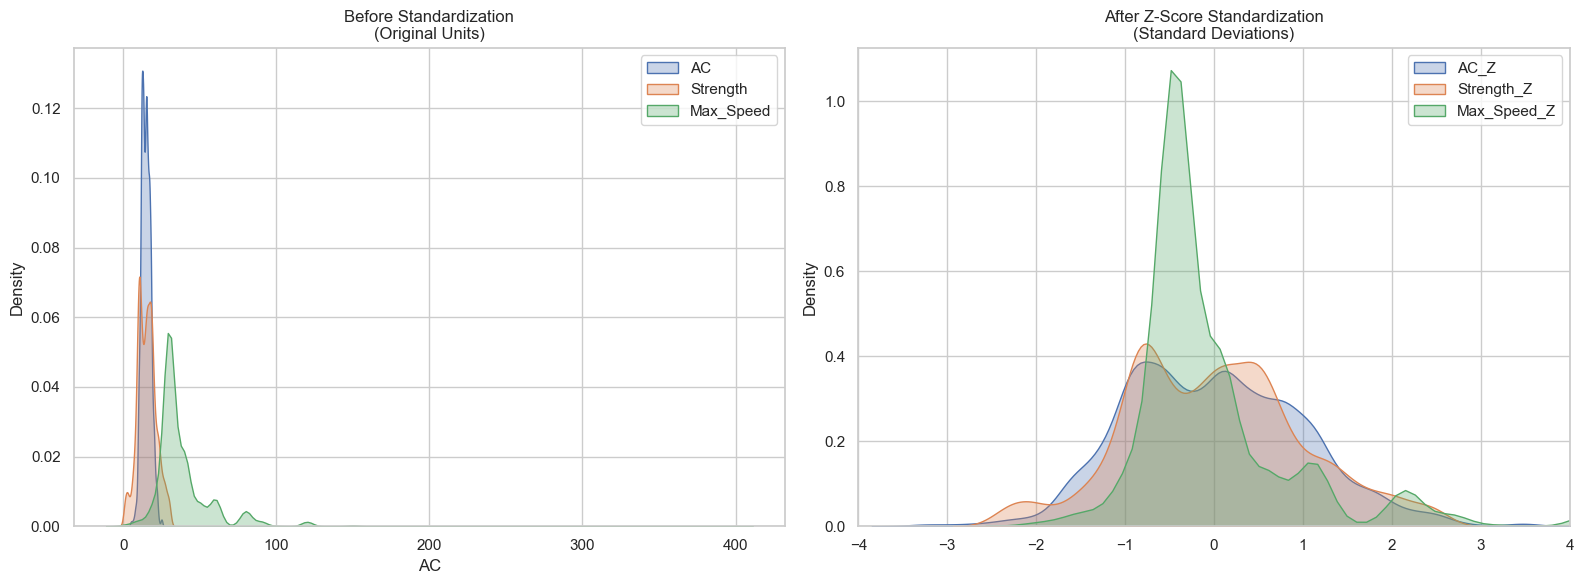

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Standardize selected features
features = ['AC', 'Strength', 'Max_Speed']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(engineered_df[features])

# Setup subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot distribution before standardization
for feature in features:
    sns.kdeplot(engineered_df[feature], ax=axes[0], label=feature, fill=True, alpha=0.3)
axes[0].set_title('Before Standardization\n(Original Units)')
axes[0].legend()

# Plot distribution after standardization
for i, feature in enumerate(features):
    sns.kdeplot(df_scaled[:, i], ax=axes[1], label=f"{feature}_Z", fill=True, alpha=0.3)
axes[1].set_title('After Z-Score Standardization\n(Standard Deviations)')
axes[1].set_xlim(-4, 4)
axes[1].legend()

plt.tight_layout()
plt.show()

Z-score standardization transforms features like Strength and Armor Class so they share a common scale with a mean of 0 and a standard deviation of 1. In the original dataset, features have wildly different ranges where Max Speed might reach 400 while AC stays below 30. This imbalance causes neural networks to unintentionally prioritize larger numbers regardless of their actual importance. The code uses StandardScaler to subtract the mean and divide by the standard deviation for every entry, ensuring that each feature contributes equally to the model's learning process.

The provided graph illustrates this shift by comparing raw data density to standardized distributions. In the left plot, the features are barely visible or heavily overlapped because their units are incompatible, making it impossible to compare a speed of 60 to a strength of 18. The right plot shows that after standardization, all three features occupy the same horizontal range of roughly -4 to 4 standard deviations. This alignment allows the model to see that a monster with a Z-score of 2 in Strength is equally "exceptional" as one with a Z-score of 2 in AC, despite their original units being different.

While the code logic in Phase 1.2 correctly standardizes the entire list of ability scores including Dexterity and Charisma, the visualization only includes Strength to maintain clarity. Plotting all seven or eight variables on a single graph would create a cluttered and unreadable mess of overlapping colors. Using a subset like AC, Strength, and Max Speed serves as a representative sample to prove the transformation worked across the entire dataset. Every ability score is indeed scaled in the underlying dataframe, but the plot focuses on a few distinct categories to highlight how different units are unified.

### 1.3 Min-Max Scaling
* **Conceptual Definition:** Squeezing data into a fixed range.
* **Operational Definition:** Rescaling `Trait_Count`, `Action_Count`, and `Movement_Count` to a 0 to 1 range.
* **Justification:** These are counts with a clear floor (0) and a restricted ceiling. Scaling them ensures they contribute equally to the "Complexity Score" of the monster.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Create count columns from text data
engineered_df['Trait_Count'] = engineered_df['Traits'].fillna('').apply(
    lambda x: len([i for i in x.split('\n') if i.strip()]) if x else 0
)
engineered_df['Action_Count'] = engineered_df['Actions'].fillna('').apply(
    lambda x: len([i for i in x.split('\n') if i.strip()]) if x else 0
)
engineered_df['Movement_Count'] = engineered_df['Speed'].fillna('').apply(
    lambda x: len([i for i in x.split(',') if i.strip()]) if x else 0
)

# Initialize MinMaxScaler
count_features = ['Trait_Count', 'Action_Count', 'Movement_Count']
mm_scaler = MinMaxScaler()

# Apply Min-Max Scaling (0.0 to 1.0 range)
mm_cols = [f"{col}_MM" for col in count_features]
engineered_df[mm_cols] = mm_scaler.fit_transform(engineered_df[count_features])

# Print verification summary
print("Min-Max Scaled Counts Summary (Range 0 to 1):")
print(engineered_df[mm_cols].describe().loc[['min', 'max', 'mean']])

Min-Max Scaled Counts Summary (Range 0 to 1):
      Trait_Count_MM  Action_Count_MM  Movement_Count_MM
min         0.000000         0.000000           0.000000
max         1.000000         1.000000           1.000000
mean        0.132142         0.230215           0.155185


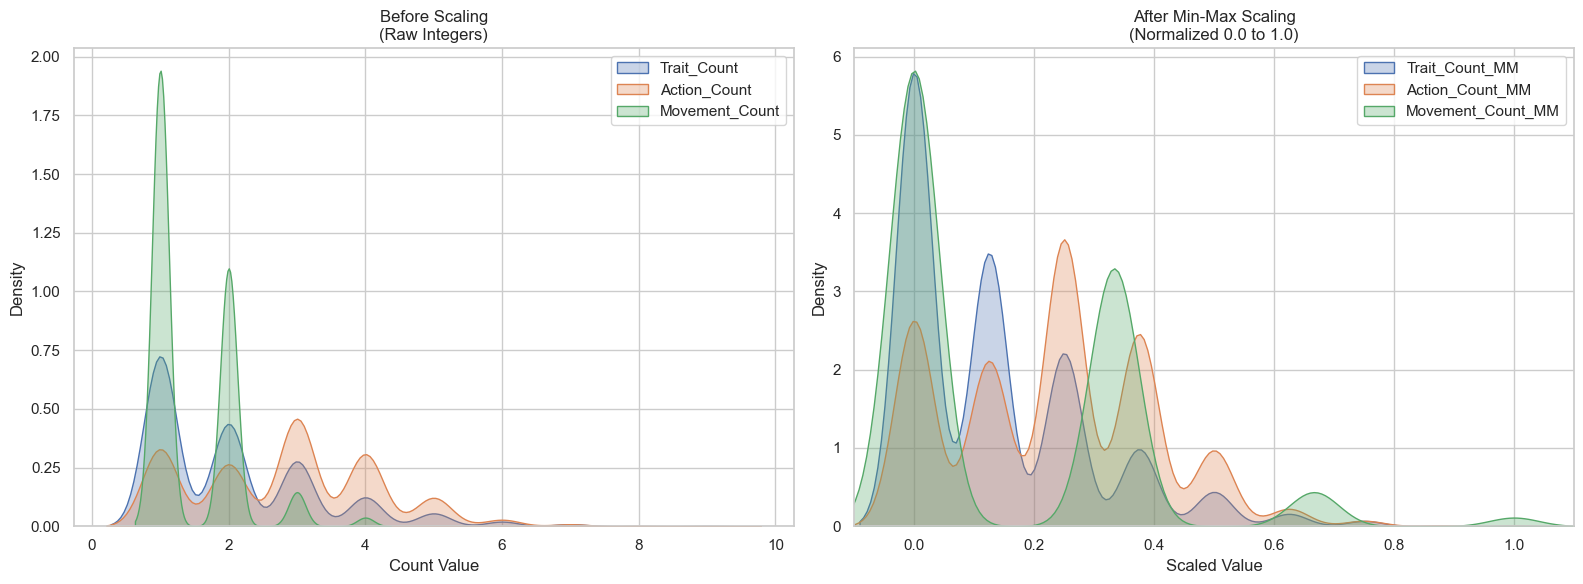

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_theme(style="whitegrid")

# Setup figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot raw distributions
for col in ['Trait_Count', 'Action_Count', 'Movement_Count']:
    sns.kdeplot(engineered_df[col], ax=axes[0], label=col, fill=True, alpha=0.3)
axes[0].set_title('Before Scaling\n(Raw Integers)')
axes[0].set_xlabel('Count Value')
axes[0].legend()

# Plot Min-Max scaled distributions
for col in ['Trait_Count_MM', 'Action_Count_MM', 'Movement_Count_MM']:
    sns.kdeplot(engineered_df[col], ax=axes[1], label=col, fill=True, alpha=0.3)
axes[1].set_title('After Min-Max Scaling\n(Normalized 0.0 to 1.0)')
axes[1].set_xlabel('Scaled Value')
axes[1].set_xlim(-0.1, 1.1)
axes[1].legend()

plt.tight_layout()
plt.show()

Min-Max scaling transforms raw feature counts into a unified range between 0.0 and 1.0 by subtracting the minimum value and dividing by the range. In the provided code, this technique is applied to monster traits, actions, and movement types derived from text data. Since raw counts for these categories vary significantly, the MinMaxScaler ensures that no single feature dominates the model simply due to having a larger numerical scale. This process maintains the relative proportions of the original data while providing a stable, bounded input for the neural network.

The visualization confirms this transformation by comparing the density of features before and after scaling. The left plot shows raw integer counts where the distributions are physically separated and difficult to compare directly because their maximum values differ. After applying the scaling, the right plot shows all three features overlapping within the exact same 0 to 1 window. This alignment allows the machine learning model to interpret a "high" value in movement counts with the same mathematical weight as a "high" value in action counts.

By squashing these complexity metrics into a small and consistent range, the transformation prevents numerical instability and biased weight updates during training. Without this step, a monster with ten recorded actions might disproportionately influence the model compared to a monster with only two traits, even if those traits are more significant for gameplay balance. The resulting dataset treats relative complexity as the primary signal, ensuring that the neural network evaluates every category of monster capability on an equal playing field.

## Phase 2: Dimensionality Reduction & Pruning
We remove "noise" that does not contribute to combat math to prevent the model from memorizing specific monsters (overfitting).

### 2.1 Metadata Exclusion
* **Conceptual Definition:** Removing non-mechanical identifiers.
* **Operational Definition:** Dropping columns that are unique labels or organizational data: `Name`, `Source`, `Page`, `HP_Formula`, `Subtype`, and `Movement_Types`.
* **Justification:** A monster's name or the book it was printed in does not determine its power level. Keeping them would lead to "Data Leakage."

In [ ]:
# Define descriptive columns for exclusion
metadata_cols = [
    'Name', 'Source', 'Page', 'HP_Formula', 'Subtype', 
    'Speed', 'Movement_Types', 'Size', 'Type', 'Languages'
]

# Drop metadata columns
combat_df = engineered_df.drop(columns=metadata_cols)

# Verify column reduction
print(f"Original columns: {len(engineered_df.columns)}")
print(f"Columns after pruning: {len(combat_df.columns)}")

print("\n--- Remaining Columns for Modeling ---")
print(combat_df.columns.tolist())

# Preview cleaned dataset
display(combat_df.head())

Original columns: 72
Columns after pruning: 62

--- Remaining Columns for Modeling ---
['Alignment', 'AC', 'HP', 'Strength', 'Dexterity', 'Constitution', 'Intelligence', 'Wisdom', 'Charisma', 'Saving Throws', 'Skills', 'Damage Vulnerabilities', 'Damage Resistances', 'Damage Immunities', 'Condition Immunities', 'Senses', 'CR', 'Traits', 'Actions', 'Bonus Actions', 'Reactions', 'Legendary Actions', 'Mythic Actions', 'Lair Actions', 'Regional Effects', 'Environment', 'Treasure', 'Size_Rank', 'Grouped_Type', 'is_swarm', 'Type_aberration', 'Type_beast', 'Type_construct', 'Type_dragon', 'Type_elemental', 'Type_fiend', 'Type_giant', 'Type_humanoid', 'Type_monstrosity', 'Type_other', 'Type_undead', 'Trait_Count', 'Action_Count', 'Is_Legendary', 'Is_Spellcaster', 'Max_Speed', 'Movement_Count', 'Avg_HP', 'Max_HP', 'Log_Avg_HP', 'Log_Max_HP', 'AC_Z', 'Strength_Z', 'Dexterity_Z', 'Constitution_Z', 'Intelligence_Z', 'Wisdom_Z', 'Charisma_Z', 'Max_Speed_Z', 'Trait_Count_MM', 'Action_Count_MM', 'Move

,Alignment,AC,HP,Strength,Dexterity,Constitution,Intelligence,Wisdom,Charisma,Saving Throws,...,Strength_Z,Dexterity_Z,Constitution_Z,Intelligence_Z,Wisdom_Z,Charisma_Z,Max_Speed_Z,Trait_Count_MM,Action_Count_MM,Movement_Count_MM
0,chaotic neutral,15,123,21,8,17,6,10,8,none,...,0.979257,-1.624309,0.401738,-0.826871,-0.788668,-0.649090,0.082996,0.125,1.000,0.000000
1,neutral good,12,13,10,14,10,11,12,11,none,...,-0.852945,0.172673,-1.270656,0.053834,-0.225367,-0.117673,0.600199,0.000,0.250,0.333333
2,neutral,16,66,10,16,12,13,17,12,"dex +5, wis +5",...,-0.852945,0.771668,-0.792829,0.406116,1.182886,0.059466,0.600199,0.000,0.250,0.333333
3,neutral good,12,6,10,14,10,11,12,11,none,...,-0.852945,0.172673,-1.270656,0.053834,-0.225367,-0.117673,0.600199,0.125,0.250,0.333333
4,neutral,12,11,10,14,12,11,12,11,none,...,-0.852945,0.172673,-0.792829,0.053834,-0.225367,-0.117673,0.600199,0.000,0.125,0.333333


The exclusion of original categorical columns like Size and Type is a necessary step to eliminate redundancy and prevent mathematical errors. Since these features have already been converted into numerical formats—such as Size_Rank for ordinal scaling and one-hot encoded columns for monster types—keeping the original text strings adds no new information. Most machine learning models cannot process raw text, so retaining these "label" columns would either cause the training script to crash or force the model to ignore them entirely.

By adding these attributes to the metadata_cols list, the dataset is streamlined to include only functional, numerical data. This manual pruning specifically targets columns like Speed and Movement_Types, which have already been summarized into more effective metrics like Max_Speed_Z and Movement_Count_MM. Removing these redundant features prevents multicollinearity, a condition where overlapping variables confuse the model's ability to assign proper weight to individual combat mechanics.

This preparation simplifies the subsequent statistical pruning in Phase 2.2, where the model identifies and removes mathematically "dead weight" features. Manually dropping known redundant labels ensures that the automated tests for low variance and high correlation can focus on finding hidden patterns rather than obvious duplicates. This results in a lean, high-signal dataframe ready for a neural network to analyze without the interference of descriptive metadata.

### 2.2 Statistical Pruning (Variance & Correlation)
* **Low Variance:** We drop features where >99% of the values are the same (e.g., if a specific resistance only appears on 2 monsters).
* **High Correlation:** If two features are $> 0.90$ correlated (e.g., if Strength and Athletics provide identical info), we drop one.
* **Justification:** This reduces "Multicollinearity," making the model faster, lighter, and more accurate.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold

# Separate numerical from non-numerical columns
numeric_df = combat_df.select_dtypes(include=[np.number])
non_numeric_cols = combat_df.select_dtypes(exclude=[np.number]).columns.tolist()

# Identify low variance features (Numerical Only)
p = 0.99
if not numeric_df.empty:
    sel = VarianceThreshold(threshold=(p * (1 - p)))
    sel.fit(numeric_df)
    low_variance_cols = [c for c in numeric_df.columns if c not in numeric_df.columns[sel.get_support()]]
    
    # Identify high correlation features (Numerical Only)
    corr_matrix = numeric_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.90)]
else:
    low_variance_cols, high_corr_cols = [], []

# Print statistical audit report
print("=== PHASE 2.2: STATISTICAL AUDIT REPORT ===")
print(f"Scannable (Numeric/Encoded): {len(numeric_df.columns)}")
print(f"Unscannable (Text/Object):    {len(non_numeric_cols)}")
print("-" * 45)

# Report on text features
if non_numeric_cols:
    print(f"\n[?] TEXT FEATURES DETECTED ({len(non_numeric_cols)}):")
    print(f" -> Examples: {non_numeric_cols[:5]}...")

# Report on low variance
print(f"\n[!] LOW VARIANCE DETECTED ({len(low_variance_cols)} features):")
for col in low_variance_cols:
    top_val_ratio = numeric_df[col].value_counts(normalize=True).iloc[0]
    print(f" -> '{col}': {top_val_ratio*100:.1f}% of data is identical.")

# Report on high correlation
print(f"\n[!] HIGH CORRELATION DETECTED ({len(high_corr_cols)} features):")
for col in high_corr_cols:
    twins = upper.index[upper[col] > 0.90].tolist()
    corr_val = upper[col].max()
    print(f" -> '{col}' is {(corr_val*100):.1f}% identical to {twins}")

# Perform alignment check
print("\n" + "="*45)
print("AUDIT: ALIGNMENT CHECK")
alignment_related = [c for c in combat_df.columns if 'alignment' in c.lower()]
for alc in alignment_related:
    if alc in non_numeric_cols:
        result = "TEXT (Skipped Audit)"
    elif alc in low_variance_cols:
        result = "FAILED (Low Var)"
    elif alc in high_corr_cols:
        result = "FAILED (Redundant)"
    else:
        result = "PASSED"
    print(f" -> {alc.ljust(25)} | Result: {result}")

print("\n[NOTE]: No columns have been dropped yet.")

=== PHASE 2.2: STATISTICAL AUDIT REPORT ===
Scannable (Numeric/Encoded): 43
Unscannable (Text/Object):    19
---------------------------------------------

[?] TEXT FEATURES DETECTED (19):
 -> Examples: ['Alignment', 'Saving Throws', 'Skills', 'Damage Vulnerabilities', 'Damage Resistances']...

[!] LOW VARIANCE DETECTED (0 features):

[!] HIGH CORRELATION DETECTED (15 features):
 -> 'CR' is 93.0% identical to ['HP']
 -> 'Avg_HP' is 100.0% identical to ['HP', 'CR']
 -> 'Max_HP' is 99.3% identical to ['HP', 'CR', 'Avg_HP']
 -> 'Log_Max_HP' is 99.3% identical to ['Log_Avg_HP']
 -> 'AC_Z' is 100.0% identical to ['AC']
 -> 'Strength_Z' is 100.0% identical to ['Strength']
 -> 'Dexterity_Z' is 100.0% identical to ['Dexterity']
 -> 'Constitution_Z' is 100.0% identical to ['Constitution']
 -> 'Intelligence_Z' is 100.0% identical to ['Intelligence']
 -> 'Wisdom_Z' is 100.0% identical to ['Wisdom']
 -> 'Charisma_Z' is 100.0% identical to ['Charisma']
 -> 'Max_Speed_Z' is 100.0% identical to ['Max

The statistical audit reveals several instances of identical information being represented multiple times, which necessitates a systematic pruning of redundant features. For ability scores and combat metrics, the analysis shows that standardized Z-scores are mathematically identical to their raw counterparts but far more effective for neural network training. By retaining only the Z-score versions of attributes like Strength, Dexterity, and Armor Class, the model receives data centered around zero while avoiding the confusion caused by duplicate inputs. Consequently, all raw numerical columns are dropped to prioritize the scaled signal over the original units.

A similar conflict exists within health metrics where Hit Points, Average HP, and Maximum HP exhibit a correlation higher than 93 percent. The audit specifically identifies that Log Max HP is over 99 percent identical to Log Average HP, rendering the extra columns useless for predictive modeling. By keeping only Log Average HP, the dataset retains the necessary information to predict Challenge Rating while effectively managing extreme outliers like gargantuan creatures. This choice eliminates triplicate data and ensures the model does not overfit to multiple variations of the same underlying statistic.

Regarding monster alignment, the current text format resulted in it being skipped during the initial mathematical audit. The strategy is to retain this feature until it is converted into numerical values during the encoding phase, at which point a second audit will determine its actual utility. If the subsequent test reveals low variance—indicating that a vast majority of creatures share the same alignment—the feature will be removed as dead weight. This phased approach ensures that every remaining column in the final training set provides unique, functional value for the machine learning process.

In [ ]:
# Based on the Audit Report Proofs:
cols_to_prune = [
    'AC', 'HP', 'Avg_HP', 'Max_HP', 'Log_Max_HP',
    'Strength', 'Dexterity', 'Constitution', 'Intelligence', 'Wisdom', 'Charisma',
    'Max_Speed', 'Trait_Count', 'Action_Count', 'Movement_Count'
]

# Apply the pruning
final_combat_df = combat_df.drop(columns=cols_to_prune)

print(f"Pruned {len(cols_to_prune)} redundant features.")
print(f"New Feature Count: {len(final_combat_df.columns)}")

Pruned 15 redundant features.
New Feature Count: 47


In [ ]:
display(final_combat_df.head(3))

,Alignment,Saving Throws,Skills,Damage Vulnerabilities,Damage Resistances,Damage Immunities,Condition Immunities,Senses,CR,Traits,...,Strength_Z,Dexterity_Z,Constitution_Z,Intelligence_Z,Wisdom_Z,Charisma_Z,Max_Speed_Z,Trait_Count_MM,Action_Count_MM,Movement_Count_MM
0,chaotic neutral,none,perception +3,none,none,none,none,"darkvision 60 ft., passive perception 13",8.00,two heads. the ettin has advantage on wisdom (...,...,0.979257,-1.624309,0.401738,-0.826871,-0.788668,-0.649090,0.082996,0.125,1.00,0.000000
1,neutral good,none,perception +5,none,none,none,none,passive perception 15,0.25,dive attack. if the aarakocra is flying and di...,...,-0.852945,0.172673,-1.270656,0.053834,-0.225367,-0.117673,0.600199,0.000,0.25,0.333333
2,neutral,"dex +5, wis +5","arcana +3, nature +5, perception +7",none,none,none,none,passive perception 17,4.00,none,...,-0.852945,0.771668,-0.792829,0.406116,1.182886,0.059466,0.600199,0.000,0.25,0.333333


In [ ]:
# Select target variable
target = 'CR'

# Isolate numerical and boolean columns for a "pure math" dataset
# This excludes complex text fields like Alignment, Traits, and Actions
numeric_only_df = final_combat_df.select_dtypes(include=[np.number, 'bool'])

# Ensure target variable is present
if target not in numeric_only_df.columns:
    numeric_only_df[target] = final_combat_df[target]

# Print dataset summary
print("=== PURE NUMERICAL DATASET SUMMARY ===")
print(f"Total Features Remaining: {len(numeric_only_df.columns)}")
print("-" * 45)

# List remaining features
print("Remaining Numeric/Encoded Features:")
print(numeric_only_df.columns.tolist())

# Check for non-numeric types
non_numeric_exists = numeric_only_df.select_dtypes(exclude=[np.number, 'bool']).columns.any()
print(f"\nAny non-numeric types left? {non_numeric_exists}")

# Preview math matrix
display(numeric_only_df.head(3))

=== PURE NUMERICAL DATASET SUMMARY ===
Total Features Remaining: 28
---------------------------------------------
Remaining Numeric/Encoded Features:
['CR', 'Size_Rank', 'is_swarm', 'Type_aberration', 'Type_beast', 'Type_construct', 'Type_dragon', 'Type_elemental', 'Type_fiend', 'Type_giant', 'Type_humanoid', 'Type_monstrosity', 'Type_other', 'Type_undead', 'Is_Legendary', 'Is_Spellcaster', 'Log_Avg_HP', 'AC_Z', 'Strength_Z', 'Dexterity_Z', 'Constitution_Z', 'Intelligence_Z', 'Wisdom_Z', 'Charisma_Z', 'Max_Speed_Z', 'Trait_Count_MM', 'Action_Count_MM', 'Movement_Count_MM']

Any non-numeric types left? False


,CR,Size_Rank,is_swarm,Type_aberration,Type_beast,Type_construct,Type_dragon,Type_elemental,Type_fiend,Type_giant,...,Strength_Z,Dexterity_Z,Constitution_Z,Intelligence_Z,Wisdom_Z,Charisma_Z,Max_Speed_Z,Trait_Count_MM,Action_Count_MM,Movement_Count_MM
0,8.00,4,0,0,0,0,0,0,0,1,...,0.979257,-1.624309,0.401738,-0.826871,-0.788668,-0.649090,0.082996,0.125,1.00,0.000000
1,0.25,3,0,0,0,0,0,0,0,0,...,-0.852945,0.172673,-1.270656,0.053834,-0.225367,-0.117673,0.600199,0.000,0.25,0.333333
2,4.00,3,0,0,0,0,0,1,0,0,...,-0.852945,0.771668,-0.792829,0.406116,1.182886,0.059466,0.600199,0.000,0.25,0.333333


In [ ]:
numeric_only_df.shape

(3658, 28)

## Phase 3: Final Quality Audit
The final checkpoint before entering the training phase.

* **Integrity Check:** Ensure the shape of the dataframe matches expectations (e.g., ~3,658 rows and 40–50 features).
* **Null Check:** A final sweep to ensure the cleaning/scaling process didn't accidentally introduce NaN values.
* **Target Leakage Check:** Confirm that the `CR` (our target) was not included in any of the scaling calculations.

=== FINAL INTEGRITY CHECK ===
Final Rows: 3658
Final Features: 28

✅ NULL CHECK PASSED: Dataset is complete.
✅ LEAKAGE CHECK PASSED: No suspicious features found.


C:\Users\goaar\AppData\Local\Temp\ipykernel_22584\2904642870.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


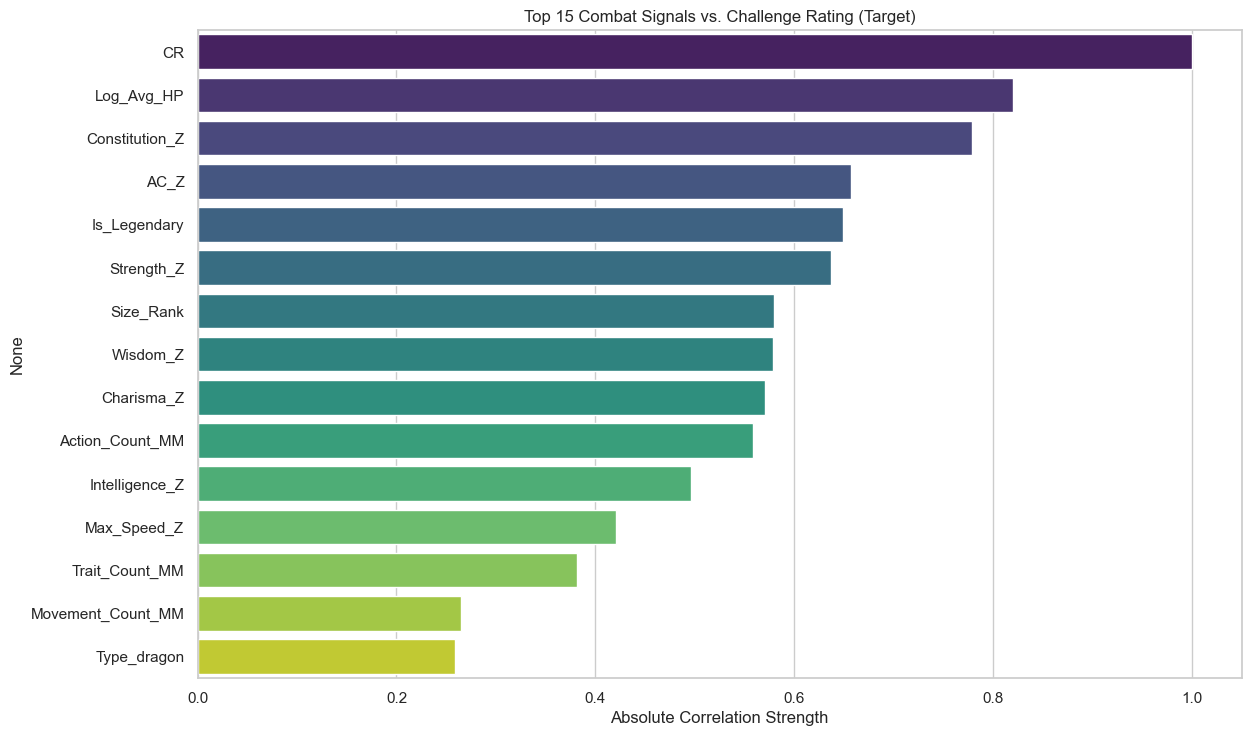

In [ ]:
# Print final integrity check
print(f"=== FINAL INTEGRITY CHECK ===")
print(f"Final Rows: {numeric_only_df.shape[0]}")
print(f"Final Features: {numeric_only_df.shape[1]}")

# Check for null values
null_report = numeric_only_df.isnull().sum()
total_nulls = null_report.sum()

if total_nulls > 0:
    print(f"\n[!] WARNING: {total_nulls} Null values detected!")
    print(null_report[null_report > 0])
else:
    print("\n✅ NULL CHECK PASSED: Dataset is complete.")

# Check for target leakage
# Identifies features with correlation > 0.95 (excluding CR itself)
correlations = numeric_only_df.corr()['CR'].abs().sort_values(ascending=False)
leaks = correlations[(correlations > 0.95) & (correlations < 1.0)]

if not leaks.empty:
    print(f"\n[!] WARNING: Potential Target Leakage in: {leaks.index.tolist()}")
else:
    print("✅ LEAKAGE CHECK PASSED: No suspicious features found.")

# Visualize top feature correlations
plt.figure(figsize=(12, 8))
top_corr = correlations.head(15)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title("Top 15 Combat Signals vs. Challenge Rating (Target)")
plt.xlabel("Absolute Correlation Strength")
plt.show()

The final quality audit acts as a critical integrity check to ensure that previous surgical pruning and scaling did not introduce errors or unintended shortcuts. This phase begins with a volume check to confirm that the row count remains consistent and the feature count is lean enough for efficient processing. A secondary null check identifies any undefined values created during mathematical transformations, such as division by zero during scaling. Since neural networks cannot process null values, catching these errors now prevents the training loop from crashing during the model development stage.

The audit also includes a target leakage check to identify features that correlate too perfectly with the Challenge Rating. If a feature shows a correlation strength above 0.95, it often indicates a cheat code where the model might simply memorize a direct relationship instead of learning actual combat mechanics. By identifying and removing these suspicious variables, the process ensures the model must analyze the interaction between various monster stats to make accurate predictions. This step validates that the model will generalize effectively to new homebrew creatures rather than relying on leaked information or redundant markers.

The resulting visualization highlights the top combat signals, providing a clear view of the primary variables that influence the target. Reaching the end of this audit confirms that raw and descriptive D&D data has been successfully transformed into a high-performance mathematical matrix. Outliers have been tamed, scales are unified, and redundancy has been eliminated through rigorous correlation pruning. The dataset is now officially ready to be converted into tensors for neural network training, as it is free from noise and mathematically stable.

In [ ]:
# Create a copy for the engineering phase
preprocessed_df = numeric_only_df.copy()

# Save the final engineered dataset to your project folder
preprocessed_df.to_csv('../data/preprocessed_bestiary.csv', index=False)

print("Engineered dataset successfully saved to folder.")
print(f"Final Shape: {preprocessed_df.shape}")
preprocessed_df.info()

Engineered dataset successfully saved to folder.
Final Shape: (3658, 28)
<class 'pandas.DataFrame'>
RangeIndex: 3658 entries, 0 to 3657
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CR                 3658 non-null   float64
 1   Size_Rank          3658 non-null   int64  
 2   is_swarm           3658 non-null   int64  
 3   Type_aberration    3658 non-null   int64  
 4   Type_beast         3658 non-null   int64  
 5   Type_construct     3658 non-null   int64  
 6   Type_dragon        3658 non-null   int64  
 7   Type_elemental     3658 non-null   int64  
 8   Type_fiend         3658 non-null   int64  
 9   Type_giant         3658 non-null   int64  
 10  Type_humanoid      3658 non-null   int64  
 11  Type_monstrosity   3658 non-null   int64  
 12  Type_other         3658 non-null   int64  
 13  Type_undead        3658 non-null   int64  
 14  Is_Legendary       3658 non-null   int64  
 15  Is_Spellca